In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [8]:
torch.manual_seed(42)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

Using device: cuda



## Importing the Dataset

In [10]:
df = pd.read_csv("fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


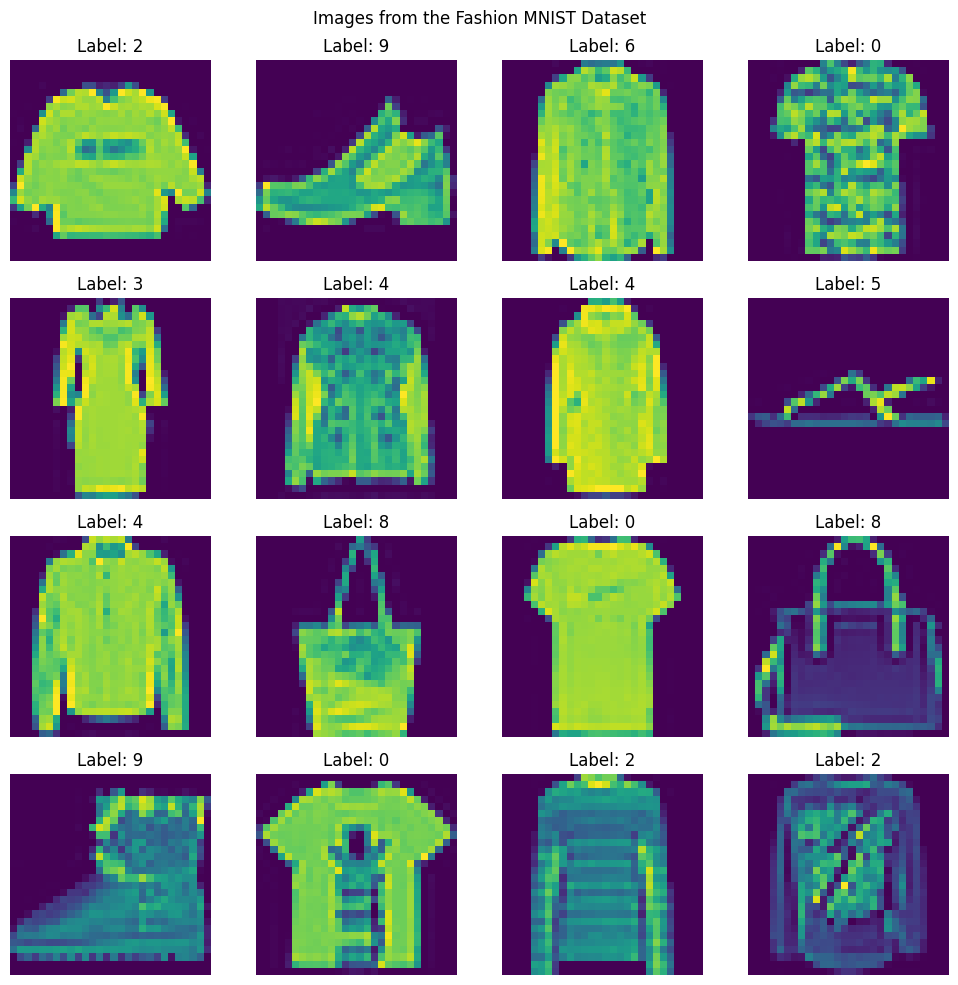

In [11]:
fig,axes = plt.subplots(4,4,figsize = (10,10))
fig.suptitle("Images from the Fashion MNIST Dataset")

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout()
plt.show()

In [12]:
df.shape

(60000, 785)

In [13]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [17]:
X_train.shape

(48000, 784)

In [18]:
X_test

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.82745098, 0.4       ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [19]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.        ,
        0.        ]])

## Transformations of the Images

In [20]:
"""Applying the transformations before the image is being sent into the Model for the preprocessing"""

from torchvision.transforms import transforms
custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) ## Values are required to be passed before passed on to the model
    ## The Values for RGB are mentioned in the VGG 16 Architecture
])

In [79]:
from PIL import Image
import numpy as np

class CustomDataset(Dataset):
  def __init__(self,features,labels,transform):
    self.features = features
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    ## Resize Image to 28x28
    image = self.features[index].reshape(28,28)

    ## Change data type to np.uint8
    image = image.astype(np.uint8)

    ## Change Black and White Color
    image = np.stack([image]*3,axis = -1)  ## basically Creates a Copy of three such Images

    ## Convert Array into PIL Image -> We Get (C,H,W)  , We Need (H,W,C)
    image = Image.fromarray(image)

    ## Apply Transformation
    image = self.transform(image)

    return image,torch.tensor(self.labels[index],dtype = torch.long)


In [80]:
train_dataset = CustomDataset(X_train,y_train,transform= custom_transform)

In [81]:
train_dataset

In [82]:
test_dataset = CustomDataset(X_test,y_test,transform= custom_transform)

In [83]:
test_dataset

In [84]:
batch_size = 32
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
"""During the Testing Phase Shuffling is kept False"""
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

## Importing the VGG 16 Model

In [85]:
import torchvision.models as models
vgg16 = models.vgg16(pretrained = True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [86]:
"""Architecture of VGG 16"""
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [87]:
"""Freexing the Training Process for Feature Paramters"""
for param in vgg16.features.parameters():
  param.requires_grad = False

In [88]:
"""Default Classfier"""
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [89]:
"""Replcing the Default Classifier without Custom CLassifier"""
vgg16.classifier = nn.Sequential(
    nn.Linear(in_features=25088,out_features=1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=1024,out_features=512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=512,out_features=10)
)

In [90]:
"""Custom Architecture"""
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [91]:
"""Moving On to the GPU Model"""
vgg16 = vgg16.to(device)

In [92]:
learning_rate = 0.0001
epochs = 10

In [93]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(),lr = learning_rate)

In [94]:
"""Training Loop"""
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features,batch_labels in train_loader:
    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    outputs = vgg16(batch_features)
    loss = criterion(outputs,batch_labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()
  print(f"Epoch: {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader)}")

Epoch: 1/10, Loss: 2.2512687363624573
Epoch: 2/10, Loss: 2.109035334030787
Epoch: 3/10, Loss: 2.012170796553294
Epoch: 4/10, Loss: 1.960666086912155
Epoch: 5/10, Loss: 1.9281148096720377
Epoch: 6/10, Loss: 1.9022759222189585
Epoch: 7/10, Loss: 1.8876673619747162
Epoch: 8/10, Loss: 1.8712354599634806
Epoch: 9/10, Loss: 1.8577625220616658
Epoch: 10/10, Loss: 1.845598771095276


## Training Accuracy

In [96]:
total_train = 0
correct_train = 0
with torch.no_grad():
  for batch_features,batch_labels in train_loader:
    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

    outputs = vgg16(batch_features)
    _, predicted = torch.max(outputs,1)
    total_train += batch_labels.shape[0]
    correct_train += (predicted == batch_labels).sum().item()
print(f"Training Accuracy : {correct_train/total_train}")

Training Accuracy : 0.3256875


## Evaluation

In [97]:
total = 0
correct = 0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:

    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

    outputs = vgg16(batch_features)
    _, predicted = torch.max(outputs,1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()
print(f"Accuracy : {correct/total}")

Accuracy : 0.31966666666666665
